# 06 · Brazilian GDP: vintages, release calendar and real-time nowcasts

A nowcast is only as honest as the information set it uses. Two things change over
time: **which** observations are available (the ragged edge, governed by the release
calendar) and **what** their values are (revisions). Most studies handle only the
first, building *pseudo* real-time vintages from today's data; but GDP revisions in
Brazil are large (Brazil's IBGE revises the whole quarterly history at every release,
and re-benchmarks it when the annual accounts arrive), so the target we evaluate
against matters.

`nowcastbox` ships the **real** vintages of the IBGE quarterly national accounts
(65 releases, June 2010 to September 2026, `load_brazil_vintages`, innovation I8) and
the **actual release dates** of GDP (`load_brazil_calendar`). This notebook:

1. measures the size of GDP revisions;
2. builds real-time vintages — pseudo real-time indicators + real GDP releases;
3. nowcasts a quarter with the information of a given day;
4. runs a short real-time evaluation against first and latest releases.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import matplotlib.pyplot as plt
import pandas as pd
from utils import (
    brazil_panel,
    brazil_realtime_store,
    display,
    gdp_growth_vintages,
    md,
    pct,
    setup,
    show,
    store_metadata,
)

import nowcastbox as nb

setup()

## 1. How much is Brazilian GDP revised?

In [2]:
vintages = nb.load_brazil_vintages()
print(vintages)
display(vintages.revision_summary(["pib", "fbcf", "consumo_familias", "pib_agropecuaria"]))

VintageStore(n_series=10, n_records=18703, n_vintages=65, vintages=2010-06-04..2026-09-01)


,n_periods,n_revised,mean_n_revisions,mean_revision,mean_abs_revision,rms_revision,std_revision,max_abs_revision,noise_to_signal
series,,,,,,,,,
pib,122,118,12.7541,1.6295,1.6820,2.5403,1.9569,8.2,0.0669
fbcf,122,121,17.2377,0.8574,3.4623,4.9881,4.9341,19.3,0.1573
consumo_familias,122,112,10.8361,1.0369,1.4943,2.1585,1.9009,6.0,0.0548
pib_agropecuaria,122,121,14.7951,3.2730,4.4336,6.1052,5.1750,20.7,0.0959


The table describes revisions of the *index levels*. For nowcasting, what matters are
revisions of the **growth rates**: we compute the quarter-on-quarter growth implied by
each vintage (`gdp_growth_vintages`, in `examples/utils`) and compare the first
release with the latest one.

In [3]:
growth = gdp_growth_vintages("pib")
triangle = growth.pivot_table(index="reference_period", columns="vintage_date", values="value")
first = triangle.apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else float("nan"), axis=1
)
latest = triangle.ffill(axis=1).iloc[:, -1]
rev = pd.DataFrame({"first release": first, "latest": latest}).loc["2010Q1":]
rev["revision"] = rev["latest"] - rev["first release"]
stats = pd.Series(
    {
        "mean revision (pp)": 100 * rev["revision"].mean(),
        "mean absolute revision (pp)": 100 * rev["revision"].abs().mean(),
        "std of revision (pp)": 100 * rev["revision"].std(),
        "std of latest growth (pp)": 100 * rev["latest"].std(),
        "share of sign changes": float((rev["first release"] * rev["latest"] < 0).mean()),
    }
)
display(stats.round(3).to_frame("QoQ GDP growth, 2010Q1 onwards"))

,"QoQ GDP growth, 2010Q1 onwards"
mean revision (pp),0.076
mean absolute revision (pp),0.412
std of revision (pp),0.552
std of latest growth (pp),1.793
share of sign changes,0.136


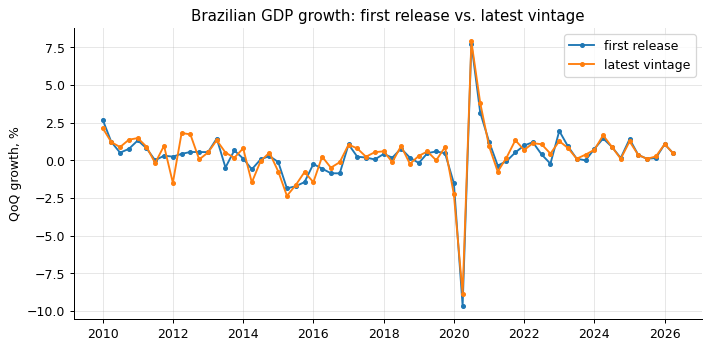

In [4]:
fig, ax = plt.subplots()
ax.plot(rev.index.to_timestamp(), 100 * rev["first release"], marker=".", label="first release")
ax.plot(rev.index.to_timestamp(), 100 * rev["latest"], marker=".", label="latest vintage")
ax.set_ylabel("QoQ growth, %")
ax.set_title("Brazilian GDP growth: first release vs. latest vintage")
ax.legend()
show(fig, "06_first_vs_latest")

The mean absolute revision of quarterly growth is a sizeable fraction of its standard
deviation, and a non-negligible share of quarters change sign between the first and
the latest estimate. In Brazil this partly reflects the seasonal adjustment being
re-estimated at every release and the annual benchmark revisions. A nowcaster
targeting the *first* release (what the press reports and what markets react to)
faces a different problem from one targeting the "true" growth rate. Revision
triangles show how a single quarter evolved:

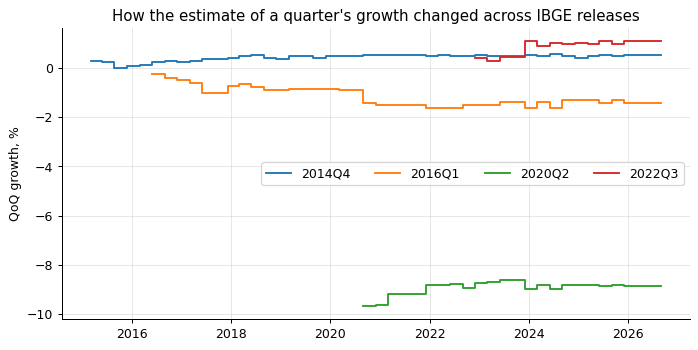

In [5]:
quarters = ["2014Q4", "2016Q1", "2020Q2", "2022Q3"]
fig, ax = plt.subplots()
for q in quarters:
    path = triangle.loc[pd.Period(q, "Q")].dropna()
    ax.step(path.index, 100 * path.to_numpy(), where="post", label=q)
ax.set_ylabel("QoQ growth, %")
ax.set_title("How the estimate of a quarter's growth changed across IBGE releases")
ax.legend(ncol=4)
show(fig, "06_revision_paths")

## 2. The release calendar

GDP is published about 60 days after the end of the quarter, on dates set by IBGE.
The shipped calendar stores the actual dates (2010Q1–2026Q2) and typical delays for
the indicators.

In [6]:
calendar = nb.load_brazil_calendar()
dates = pd.Series(
    {q: calendar.release_date("pib", q) for q in pd.period_range("2023Q1", "2026Q2", freq="Q")}
)
lag = (dates - pd.PeriodIndex(dates.index).to_timestamp(how="end").normalize()).dt.days
display(pd.DataFrame({"GDP release date": dates.dt.date, "days after quarter end": lag}))

,GDP release date,days after quarter end
2023Q1,2023-06-01,62
2023Q2,2023-09-01,63
2023Q3,2023-12-05,66
2023Q4,2024-03-01,61
2024Q1,2024-06-04,65
2024Q2,2024-09-03,65
2024Q3,2024-12-03,64
2024Q4,2025-03-07,66
2025Q1,2025-05-30,60
2025Q2,2025-09-02,64


## 3. Real-time vintages: pseudo real-time indicators + real GDP

We use the compact 22-series panel of the examples (GDP plus 21 monthly indicators,
see `utils.BRAZIL_CORE`). The monthly indicators are cut with the calendar (their own
revisions are not available — the "pseudo" part), while GDP takes the value published
by IBGE in each vintage.

In [7]:
ds, panel = brazil_panel(start="2005-01")
store = brazil_realtime_store(panel, calendar)
print(store)

VintageStore(n_series=22, n_records=11113, n_vintages=2810, vintages=2005-02-28..2026-10-01)


In [8]:
day = "2024-08-15"
real_time = store.as_of(day, as_mixed=True, **store_metadata(panel))
pseudo_rt = nb.pseudo_real_time(panel, calendar=calendar, vintage=day)
compare = pd.DataFrame(
    {
        f"real time ({day})": real_time.to_native("pib"),
        "pseudo real time (today's data)": pseudo_rt.to_native("pib"),
    }
).loc["2023Q1":"2024Q2"]
display(compare.map(pct))

,real time (2024-08-15),pseudo real time (today's data)
period,,
2023Q1,1.28%,1.33%
2023Q2,0.88%,0.79%
2023Q3,0.05%,0.14%
2023Q4,-0.05%,0.37%
2024Q1,0.76%,0.66%
2024Q2,n/a,n/a


On 15 August 2024 GDP for 2024Q2 was not yet out (it was released on 3 September).
The values for 2023 seen on that day differ from today's estimates by up to several
tenths of a percentage point: a pseudo real-time exercise would have used information
nobody had.

## 4. A nowcast with the information of one day

In [9]:
model = nb.MixedFreqDFM(n_factors=1, factor_lags=1, max_iter=200)
res = model.fit(real_time, target="pib")
target_q = pd.Period("2024Q2", "Q")
first_release = first.loc[target_q]
md(
    f"Nowcast of 2024Q2 GDP growth on {day}: **{pct(res.get_nowcast(target_q))}** QoQ. "
    f"IBGE's first release (3 Sep 2024): **{pct(first_release)}**; latest vintage: "
    f"**{pct(latest.loc[target_q])}**."
)

Nowcast of 2024Q2 GDP growth on 2024-08-15: **0.69%** QoQ. IBGE's first release (3 Sep 2024): **1.45%**; latest vintage: **1.66%**.

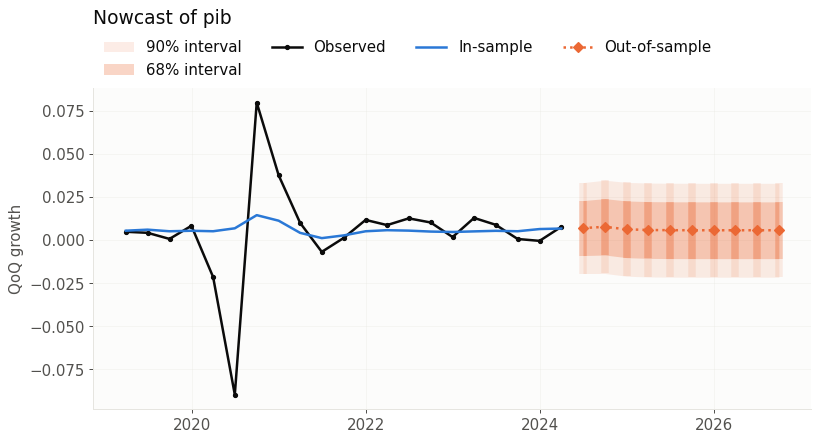

In [10]:
fig = res.plot("forecast", backend="matplotlib", start="2019Q1", ylabel="QoQ growth")
show(fig, "06_realtime_nowcast")

The second quarter of 2024 is a useful reminder of what a nowcast is: the first
release surprised most forecasters on the upside (household consumption and
investment were much stronger than the monthly surveys suggested), and a factor model
that reads only the common component of the monthly panel misses such idiosyncratic
surprises. One quarter says little about accuracy; section 5 measures it over many.

## 5. A real-time evaluation, 2012–2019

`PseudoRealTimeBacktest` accepts a `VintageStore`: at each monthly vintage date the
model is estimated on `store.as_of(date)` — the GDP history *as published at that
date*. The `actual` argument chooses the realisation the forecasts are scored against:
the **first** release or the **latest** vintage. We stop in 2019 to keep the pandemic
out (notebook 10) and re-estimate parameters every three months (`refit_every=3`;
in between, the Kalman filter updates the nowcast with the new data).

In [11]:
tables = {}
for actual in ("first", "latest"):
    backtest = nb.PseudoRealTimeBacktest(
        model=nb.MixedFreqDFM(n_factors=1, max_iter=50),
        data=store,
        target="pib",
        start="2012-01-15",
        end="2019-12-15",
        step="M",
        benchmarks=[nb.benchmarks.AR(p=1)],
        actual=actual,
        refit_every=3,
        metadata=store_metadata(panel),
        n_jobs=4,
    )
    out = backtest.run()
    tables[actual] = 100 * out.rmsfe_by_horizon()
summary = pd.concat(tables, axis=1, names=["scored against", "model"])
display(summary.round(3))

scored against        first              latest       
model          MixedFreqDFM     AR MixedFreqDFM     AR
months_to_end                                         
-2                    0.549  0.898        0.720  1.063
-1                    0.570  0.898        0.731  1.063
 0                    0.576  0.895        0.763  1.063
 1                    0.810  0.988        1.042  1.142
 2                    0.764  0.988        0.987  1.142
 3                    0.977  1.051        1.129  1.181
 4                    0.981  1.066        1.128  1.190
 5                    0.993  1.066        1.141  1.190

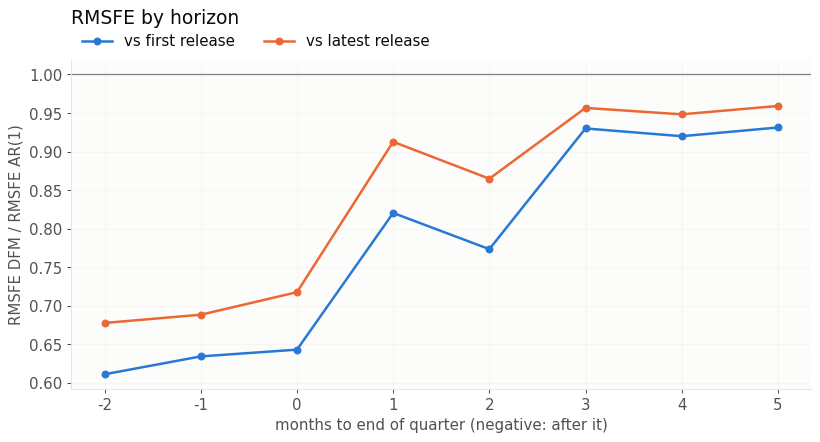

In [12]:
ratio = pd.DataFrame({k: v["MixedFreqDFM"] / v["AR"] for k, v in tables.items()}).rename(
    columns=lambda c: f"vs {c} release"
)
fig = nb.visualization.plot_rmsfe_by_horizon(
    ratio, backend="matplotlib", xlabel="months to end of quarter (negative: after it)"
)
fig.axes[0].axhline(1.0, color="grey", lw=1)
fig.axes[0].set_ylabel("RMSFE DFM / RMSFE AR(1)")
show(fig, "06_realtime_eval")

**Reading.** In real time the DFM improves steadily on the AR(1) as the quarter's data
arrive: from roughly the same accuracy when the quarter has not started
(`months_to_end` = 3–5) to RMSFE ratios of about 0.6–0.7 at the end of the quarter
and before the release (negative horizons). The gains are larger when the nowcast is
scored against the **first release**: the monthly indicators carry information about
the early estimate of GDP — which IBGE itself builds partly from the same monthly
surveys — more than about its revisions. The choice of target should match the use:
markets and the press react to the first release; structural analysis cares about the
latest estimate.

### References

* Croushore, D. (2011). Frontiers of real-time data analysis. *Journal of Economic
  Literature*, 49(1), 72–100.
* Giannone, D., Reichlin, L. & Small, D. (2008). *Journal of Monetary Economics*,
  55(4), 665–676.
* Bańbura, M. & Modugno, M. (2014). *Journal of Applied Econometrics*, 29(1), 133–160.
* IBGE — Sistema de Contas Nacionais Trimestrais, release history (source of
  `load_brazil_vintages`).